# Оценка состояния: обзор входных данных и сравнение с результатом

Загрузка NPZ-файла → просмотр входных таблиц → запуск SE → сравнение вход/выход.

Доступные тестовые случаи:
- `from_sql` — исходные данные из SQL (сырые измерения)
- `before_oc` — после оценки Астры, до оптимального управления
- `after_oc` — после оценки Астры + оптимальное управление

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gridstate.contract import SE_INPUT, SE_OUTPUT
from gridstate.contract import run as se_run
from gridstate.contract.serialize import load_se_input_npz
from gridstate.pipeline import PipelineConfig

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

CASES_DIR = Path("..") / ".specs" / "test_cases"
CASES = {
    "from_sql":  CASES_DIR / "odu_severo_zapada_from_sql.npz",
    "before_oc": CASES_DIR / "odu_severo_zapada_before_oc.npz",
    "after_oc":  CASES_DIR / "odu_severo_zapada_after_oc.npz",
}

## 1. Выбор тестового случая

In [2]:
# Укажите нужный случай: "from_sql", "before_oc" или "after_oc"
CASE = "after_oc"

path = CASES[CASE]
assert path.exists(), f"Файл не найден: {path}"
print(f"Загрузка: {path.name} ({path.stat().st_size / 1024:.0f} KB)")

se_input = load_se_input_npz(path)
print(f"contract_version = {se_input.contract_version}")
print(f"derived = {'есть' if se_input.derived else 'нет'}")

Загрузка: odu_severo_zapada_after_oc.npz (341 KB)
contract_version = 1.0.0
derived = нет


## 2. Обзор входных данных

In [3]:
model = se_input.model

for name in ("nodes", "branches", "measurements", "generators",
            "tap_steps", "load_characteristics", "shunts"):
    coll = getattr(model, name, None)
    n = len(coll) if coll is not None else 0
    cols = ", ".join(coll.to_numpy().dtype.names) if n > 0 else "—"
    print(f"{name:22s} {n:>6d} строк   cols: {cols}")

nodes                    2152 строк   cols: id, name, area_id, voltage_nominal, voltage_min, voltage_max, voltage_critical, voltage_setpoint, exist_load, exist_gen, sxn_id, load_model_id, load_p_min, load_p_max, load_q_min, load_q_max, status, node_type, balance_priority, shunt_g, shunt_b, generation_p, generation_q, generation_p_min, generation_p_max, generation_q_min, generation_q_max, load_p, load_q, voltage_magnitude, voltage_angle, p_inj_calc, q_inj_calc, imbalance_p, imbalance_q, load_p_estimated, load_q_estimated, generation_p_estimated, generation_q_estimated
branches                 2918 строк   cols: id, from_node, to_node, parallel_id, name, branch_type, current_limit_normal, ti_p_from, ti_q_from, ti_p_to, ti_q_to, status, resistance, reactance, conductance, susceptance, conductance_from, susceptance_from, conductance_to, susceptance_to, tap_ratio, phase_shift, tap_step_id, tap_side, tap_min, tap_max, power_from_p, power_from_q, power_to_p, power_to_q, current_from, current_

In [4]:
nodes_in = pd.DataFrame(np.asarray(model.nodes.to_numpy()))
print(f"Узлы: {len(nodes_in)}")
nodes_in.head(10)

Узлы: 2152


,id,name,area_id,voltage_nominal,voltage_min,voltage_max,voltage_critical,voltage_setpoint,exist_load,exist_gen,sxn_id,load_model_id,load_p_min,load_p_max,load_q_min,load_q_max,status,node_type,balance_priority,shunt_g,shunt_b,generation_p,generation_q,generation_p_min,generation_p_max,generation_q_min,generation_q_max,load_p,load_q,voltage_magnitude,voltage_angle,p_inj_calc,q_inj_calc,imbalance_p,imbalance_q,load_p_estimated,load_q_estimated,generation_p_estimated,generation_q_estimated
0,1001,Нива 1,13,10.5,9.45,11.55,7.35,0.00000,1,0,0,0,0.01,1.50,0.0,0.9,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.012184,0.000168,10.363369,0.883148,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1002,Нива 2,13,10.5,9.45,11.55,7.35,0.00000,1,0,0,0,0.01,0.90,0.0,0.3,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.216488,0.317001,10.236136,0.907227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1003,Нива 3,13,10.5,9.40,11.60,7.35,0.00000,1,0,0,0,0.01,110.00,0.0,70.0,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,31.714971,2.385825,10.840795,0.932972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1004,Кайтакоски ГЭС-4,13,6.3,5.67,6.93,4.41,0.00000,1,0,0,0,0.00,1.00,0.0,0.4,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.078475,0.319558,6.855965,0.991454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1005,Янискоски ГЭС-5,13,6.3,5.67,6.93,4.41,0.00000,1,0,0,0,0.00,0.50,0.0,0.3,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.110403,0.240447,6.848481,1.012814,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1006,Раякоски ГЭС-6,13,10.5,9.45,11.55,7.35,0.00000,1,0,0,0,0.00,2.00,0.0,0.5,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.113421,0.457078,10.889145,0.996712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1008,Борисоглебская ГЭС-8,13,10.5,9.45,11.55,7.35,0.00000,1,0,0,0,0.01,1.65,0.0,1.0,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.221473,0.331344,10.613966,0.920520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1009,Кумская ГЭС-9 СШ10кВ,13,10.5,9.40,11.60,7.35,0.00000,1,0,0,0,0.01,10.00,0.0,5.0,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.194716,0.000062,10.269644,0.847484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1010,Иовская ГЭС-10 СШ10кВ,13,10.5,9.40,11.60,7.35,0.00000,0,0,0,0,0.00,0.00,0.0,0.0,True,0,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,10.451484,0.884679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1011,Княжегубская ГЭС-11 Г1,13,10.5,9.45,11.55,7.35,10.72146,0,1,0,0,0.00,0.00,0.0,0.0,True,1,0,0.0,0.0,35.163306,2.276396,0.0,40.0,-10.0,19.0,0.000000,0.000000,10.721460,0.924582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


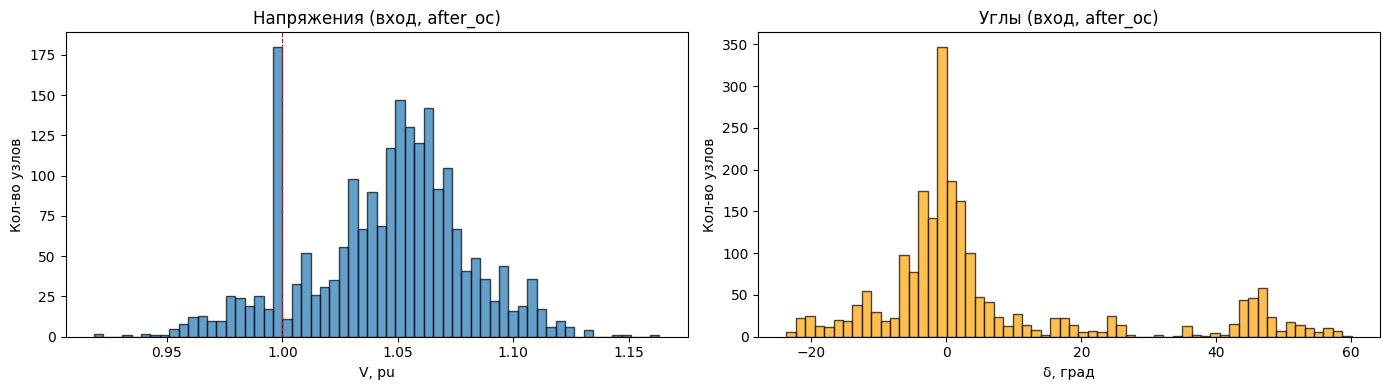

V: [0.9184, 1.1632] pu,  mean=1.0448
δ: [-23.69°, 60.07°],  mean=5.64°


In [5]:
# Напряжения (вход)
v_kV = nodes_in["voltage_magnitude"]
vnom = nodes_in["voltage_nominal"]
v_pu = v_kV / vnom
delta = nodes_in["voltage_angle"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(v_pu, bins=60, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("V, pu")
axes[0].set_ylabel("Кол-во узлов")
axes[0].set_title(f"Напряжения (вход, {CASE})")
axes[0].axvline(1.0, color="red", ls="--", lw=0.8)

axes[1].hist(np.degrees(delta), bins=60, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_xlabel("δ, град")
axes[1].set_ylabel("Кол-во узлов")
axes[1].set_title(f"Углы (вход, {CASE})")

plt.tight_layout()
plt.show()

print(f"V: [{v_pu.min():.4f}, {v_pu.max():.4f}] pu,  mean={v_pu.mean():.4f}")
print(f"δ: [{np.degrees(delta.min()):.2f}°, {np.degrees(delta.max()):.2f}°],  mean={np.degrees(delta.mean()):.2f}°")

In [6]:
meas_in = pd.DataFrame(np.asarray(model.measurements.to_numpy()))
print(f"Измерения: {len(meas_in)}")

# Типы измерений (meas_type)
if "meas_type" in meas_in.columns:
    print("\nПо типам:")
    display(meas_in.groupby("meas_type").agg(
        count=("id", "size"),
        mean_value=("value", "mean"),
        std_value=("value", "std"),
    ))

meas_in.head(25)

Измерения: 4631


,id,object_type,object_id,measurement_type,min_value,max_value,name,formula,source_numer,tip_ti,prv_num,validity_timeout,guid_measurement,value,variance,weight,status,quality,branch_side,is_pseudo,filter_flag,source_code,source_guid,estimated_si,estimated_value,residual
0,1,0,1001,2,-9999.0,9999.0,,,0,,,0,,10.37217,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
1,2,0,1002,2,-9999.0,9999.0,,,0,,,0,,10.04423,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
2,3,0,1005,2,-9999.0,9999.0,,,0,,,0,,6.88990,0.010000,100.000000,True,0,-1,False,0,,,0.0,0.0,0.0
3,4,0,1006,2,-9999.0,9999.0,,,0,,,0,,10.91358,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
4,5,0,1008,2,-9999.0,9999.0,,,0,,,0,,10.63281,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
5,6,0,1009,2,-9999.0,9999.0,,,0,,,0,,10.33639,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
6,7,0,1010,2,-9999.0,9999.0,,,0,,,0,,10.47583,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
7,8,0,1011,2,-9999.0,9999.0,,,0,,,0,,10.71605,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
8,9,0,1012,2,-9999.0,9999.0,,,0,,,0,,10.54579,0.011025,90.702948,True,0,-1,False,0,,,0.0,0.0,0.0
9,10,0,1013,2,-9999.0,9999.0,,,0,,,0,,6.32763,0.010000,100.000000,True,0,-1,False,0,,,0.0,0.0,0.0


In [7]:
branches_in = pd.DataFrame(np.asarray(model.branches.to_numpy()))
print(f"Ветви: {len(branches_in)}")
branches_in.head()

Ветви: 2918


,id,from_node,to_node,parallel_id,name,branch_type,current_limit_normal,ti_p_from,ti_q_from,ti_p_to,ti_q_to,status,resistance,reactance,conductance,susceptance,conductance_from,susceptance_from,conductance_to,susceptance_to,tap_ratio,phase_shift,tap_step_id,tap_side,tap_min,tap_max,power_from_p,power_from_q,power_to_p,power_to_q,current_from,current_to,loss_p,loss_q,loading_pct
0,1,3670,3116,1,Копорская 330 (Присоед. ЛАЭС блок1) - ЛАЭС Блок 5,1,0.0,0,0,0,0,True,0.200,11.00,0.0,0.000000,0.0,0.0,0.0,0.0,14.492754,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,36681,40393063,1,Копорская 330 (Присоед. Коп-Гатч) - ПС 330 кВ ...,0,0.0,0,0,0,0,True,2.415,29.75,0.0,-0.000342,0.0,0.0,0.0,0.0,1.000000,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,3161,3089,1,ПС 330 кВ Парнас СШ110 - ПС 110 кВ Поэтическая...,0,0.0,0,0,0,0,True,0.340,1.77,0.0,-0.000058,0.0,0.0,0.0,0.0,1.000000,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,3561,3161,1,ПС 110 кВ Никитинская (ПС 212) - ПС 330 кВ Пар...,0,0.0,0,0,0,0,True,0.200,0.40,0.0,-0.000010,0.0,0.0,0.0,0.0,1.000000,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,3904,3926,1,Северная (330 кВ) - ПС 330 кВ Парнас СШ330,0,0.0,0,0,0,0,True,0.600,6.30,0.0,-0.000096,0.0,0.0,0.0,0.0,1.000000,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Запуск оценки состояния

In [8]:
ALGORITHM = "wls"  # "wls" или "ipm"

result = se_run(se_input, config=PipelineConfig(algorithm=ALGORITHM), validate=False)
print(f"Алгоритм:     {result.algorithm}")
print(f"Успех:        {result.success}")
print(f"Итерации:     {result.iterations}")
print(f"Целевая ф-я:  {result.objective_value:.6f}")
print(f"Узлов (out):  {len(result.nodes)}")
print(f"Ветвей (out): {len(result.branches)}")
print(f"Изм. (out):   {len(result.measurements)}")

Алгоритм:     wls
Успех:        True
Итерации:     5
Целевая ф-я:  109065.157820
Узлов (out):  2152
Ветвей (out): 2918
Изм. (out):   9116


## 4. Сравнение: вход vs выход

Входные данные (Астра) сопоставляются с результатом gridstate по `id`.

In [9]:
def _align_by_id(input_arr, output_arr):
    """Выровнять input и output по id, вернуть (common_ids, in_data, out_data)."""
    in_idx = {int(x): i for i, x in enumerate(input_arr["id"])}
    out_idx = {int(x): i for i, x in enumerate(output_arr["id"])}
    common = sorted(set(in_idx) & set(out_idx))
    i_sel = np.array([in_idx[n] for n in common])
    o_sel = np.array([out_idx[n] for n in common])
    return common, input_arr[i_sel], output_arr[o_sel]

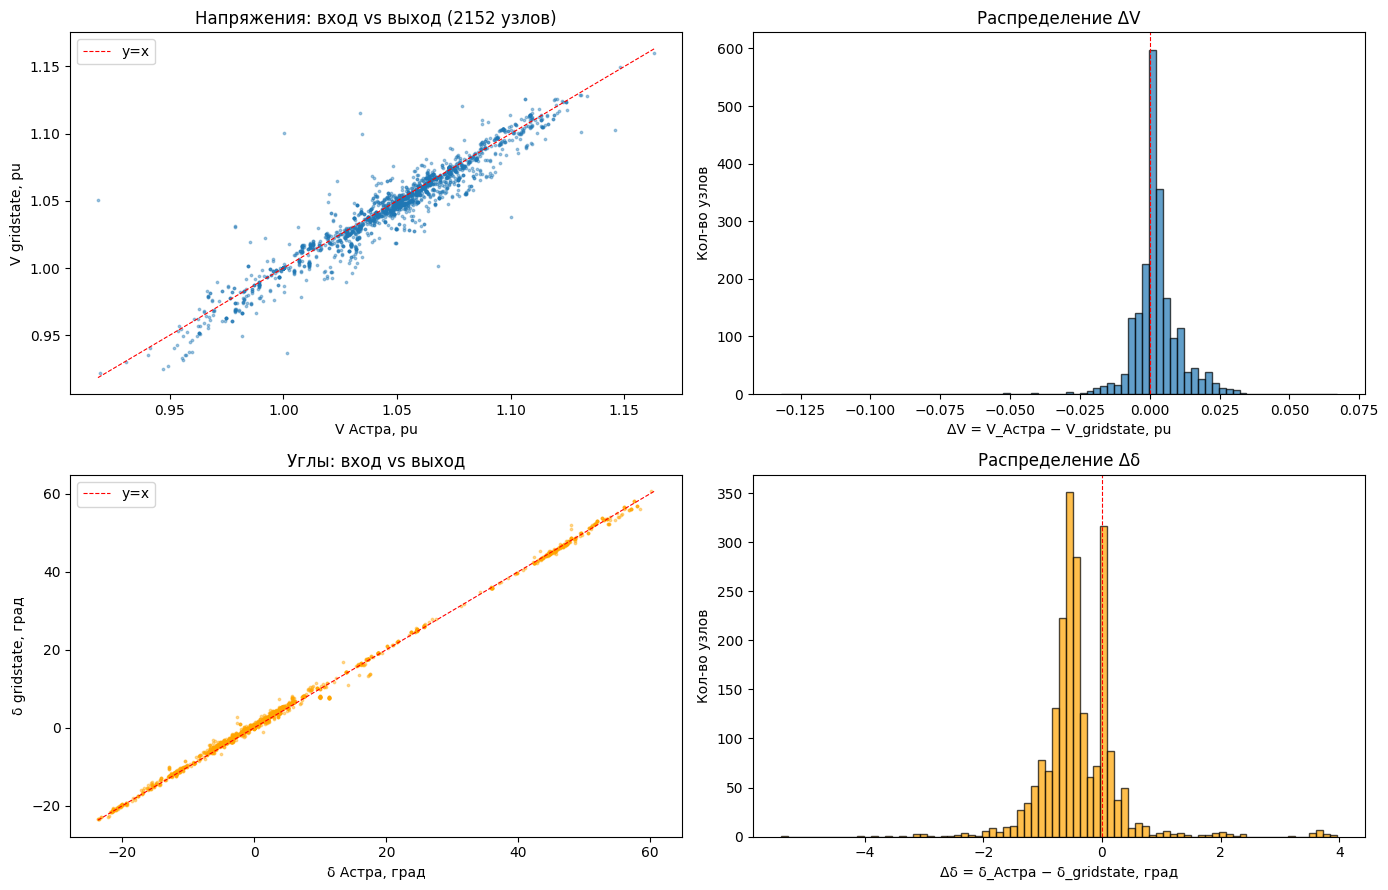

ΔV: max=0.132150 pu, mean=0.005869 pu
Δδ: max=5.4168°, mean=0.5771°
  |ΔV| > 0.01 pu: 389 узлов
  |ΔV| > 0.05 pu: 9 узлов


In [10]:
nodes_in_arr = np.asarray(model.nodes.to_numpy())
nodes_out_arr = np.asarray(result.nodes)
ids, n_in, n_out = _align_by_id(nodes_in_arr, nodes_out_arr)

vnom = n_in["voltage_nominal"]
v_astra_pu = n_in["voltage_magnitude"] / vnom
v_gs_kV = n_out["voltage_magnitude"]
v_gs_pu = v_gs_kV / vnom
delta_astra = n_in["voltage_angle"]
delta_gs = n_out["voltage_angle"]

dv = v_astra_pu - v_gs_pu
dd = delta_astra - delta_gs

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# V: scatter
ax = axes[0, 0]
ax.scatter(v_astra_pu, v_gs_pu, s=3, alpha=0.4)
lo, hi = min(v_astra_pu.min(), v_gs_pu.min()), max(v_astra_pu.max(), v_gs_pu.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=0.8, label="y=x")
ax.set_xlabel("V Астра, pu")
ax.set_ylabel("V gridstate, pu")
ax.set_title(f"Напряжения: вход vs выход ({len(ids)} узлов)")
ax.legend()

# V: histogram of diff
ax = axes[0, 1]
ax.hist(dv, bins=80, edgecolor="black", alpha=0.7)
ax.set_xlabel("ΔV = V_Астра − V_gridstate, pu")
ax.set_ylabel("Кол-во узлов")
ax.set_title(f"Распределение ΔV")
ax.axvline(0, color="red", ls="--", lw=0.8)

# δ: scatter
ax = axes[1, 0]
ax.scatter(np.degrees(delta_astra), np.degrees(delta_gs), s=3, alpha=0.4, color="orange")
lo, hi = min(delta_astra.min(), delta_gs.min()), max(delta_astra.max(), delta_gs.max())
ax.plot([np.degrees(lo), np.degrees(hi)], [np.degrees(lo), np.degrees(hi)], "r--", lw=0.8, label="y=x")
ax.set_xlabel("δ Астра, град")
ax.set_ylabel("δ gridstate, град")
ax.set_title("Углы: вход vs выход")
ax.legend()

# δ: histogram of diff
ax = axes[1, 1]
ax.hist(np.degrees(dd), bins=80, edgecolor="black", alpha=0.7, color="orange")
ax.set_xlabel("Δδ = δ_Астра − δ_gridstate, град")
ax.set_ylabel("Кол-во узлов")
ax.set_title("Распределение Δδ")
ax.axvline(0, color="red", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

print(f"ΔV: max={np.abs(dv).max():.6f} pu, mean={np.abs(dv).mean():.6f} pu")
print(f"Δδ: max={np.degrees(np.abs(dd).max()):.4f}°, mean={np.degrees(np.abs(dd).mean()):.4f}°")
print(f"  |ΔV| > 0.01 pu: {np.sum(np.abs(dv) > 0.01)} узлов")
print(f"  |ΔV| > 0.05 pu: {np.sum(np.abs(dv) > 0.05)} узлов")

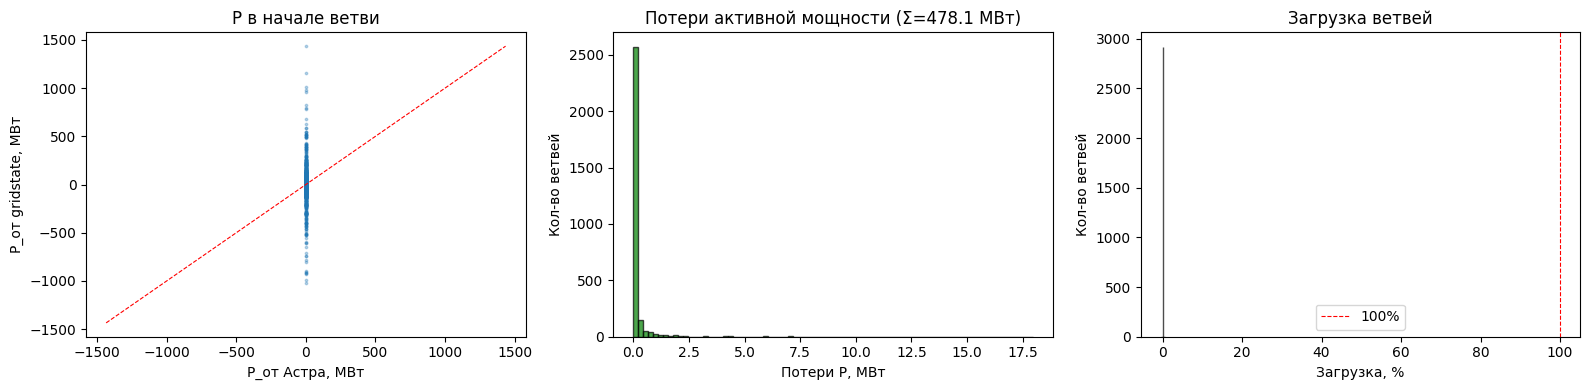

In [11]:
branches_in_arr = np.asarray(model.branches.to_numpy())
branches_out_arr = np.asarray(result.branches)
_, br_in, br_out = _align_by_id(branches_in_arr, branches_out_arr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# P from
pf_in = br_in["power_from_p"] if "power_from_p" in br_in.dtype.names else np.zeros(len(br_in))
pf_out = br_out["power_from_p"]
axes[0].scatter(pf_in, pf_out, s=3, alpha=0.3)
axes[0].set_xlabel("P_от Астра, МВт")
axes[0].set_ylabel("P_от gridstate, МВт")
axes[0].set_title("P в начале ветви")
rng = max(np.abs(pf_in).max(), np.abs(pf_out).max())
axes[0].plot([-rng, rng], [-rng, rng], "r--", lw=0.8)

# Losses
loss = br_out["loss_p"]
axes[1].hist(loss, bins=80, edgecolor="black", alpha=0.7, color="green")
axes[1].set_xlabel("Потери P, МВт")
axes[1].set_ylabel("Кол-во ветвей")
axes[1].set_title(f"Потери активной мощности (Σ={loss.sum():.1f} МВт)")

# Loading
loading = br_out["loading_pct"]
axes[2].hist(loading, bins=80, edgecolor="black", alpha=0.7, color="purple")
axes[2].set_xlabel("Загрузка, %")
axes[2].set_ylabel("Кол-во ветвей")
axes[2].set_title("Загрузка ветвей")
axes[2].axvline(100, color="red", ls="--", lw=0.8, label="100%")
axes[2].legend()

plt.tight_layout()
plt.show()

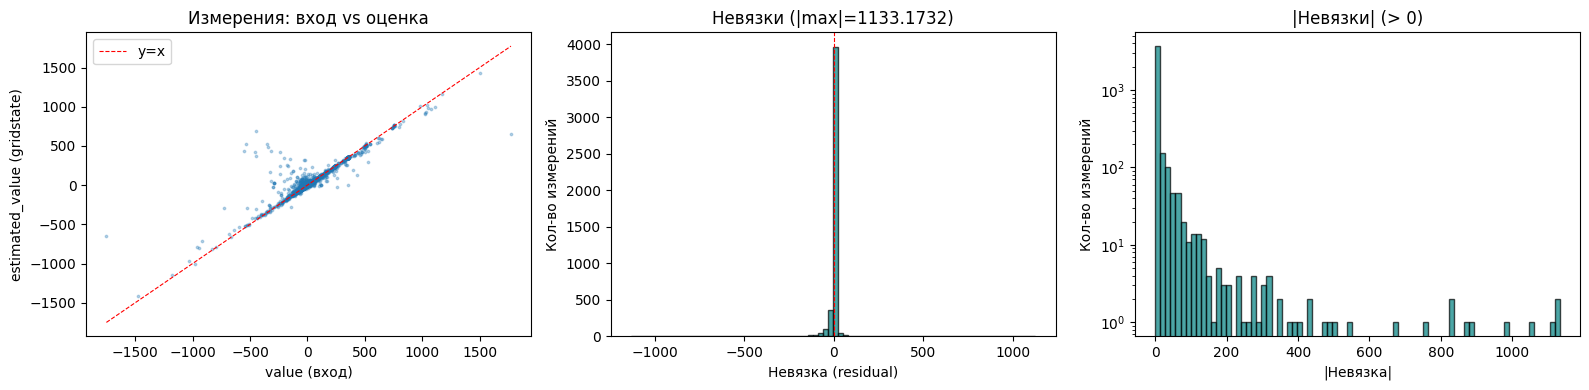

Измерений: 4631
Невязки: max=1133.1732, mean=10.3084, median=0.4332
  |residual| > 1:  1756
  |residual| > 5:  803
  |residual| > 10: 556


In [12]:
meas_in_arr = np.asarray(model.measurements.to_numpy())
meas_out_arr = np.asarray(result.measurements)
_, m_in, m_out = _align_by_id(meas_in_arr, meas_out_arr)

value_in = m_in["value"]
est_val = m_out["estimated_value"]
est_si = m_out["estimated_si"]
residual = m_out["residual"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# value vs estimated_value
axes[0].scatter(value_in, est_val, s=3, alpha=0.3)
lo = min(value_in.min(), est_val.min())
hi = max(value_in.max(), est_val.max())
axes[0].plot([lo, hi], [lo, hi], "r--", lw=0.8, label="y=x")
axes[0].set_xlabel("value (вход)")
axes[0].set_ylabel("estimated_value (gridstate)")
axes[0].set_title("Измерения: вход vs оценка")
axes[0].legend()

# Residual distribution
axes[1].hist(residual, bins=80, edgecolor="black", alpha=0.7, color="teal")
axes[1].set_xlabel("Невязка (residual)")
axes[1].set_ylabel("Кол-во измерений")
axes[1].set_title(f"Невязки (|max|={np.abs(residual).max():.4f})")
axes[1].axvline(0, color="red", ls="--", lw=0.8)

# |Residual| distribution (log)
abs_res = np.abs(residual)
axes[2].hist(abs_res[abs_res > 0], bins=80, edgecolor="black", alpha=0.7, color="teal")
axes[2].set_xlabel("|Невязка|")
axes[2].set_ylabel("Кол-во измерений")
axes[2].set_title("|Невязки| (> 0)")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Измерений: {len(m_in)}")
print(f"Невязки: max={abs_res.max():.4f}, mean={abs_res.mean():.4f}, median={np.median(abs_res):.4f}")
print(f"  |residual| > 1:  {np.sum(abs_res > 1)}")
print(f"  |residual| > 5:  {np.sum(abs_res > 5)}")
print(f"  |residual| > 10: {np.sum(abs_res > 10)}")

In [13]:
# Топ-20 наибольших невязок
meas_df = pd.DataFrame({
    "id": m_in["id"],
    "value": value_in,
    "estimated": est_val,
    "residual": residual,
    "abs_residual": np.abs(residual),
})
if "meas_type" in m_in.dtype.names:
    meas_df["meas_type"] = m_in["meas_type"]

worst = meas_df.nlargest(20, "abs_residual")
print("Топ-20 наибольших |невязок|:")
display(worst)

Топ-20 наибольших |невязок|:


,id,value,estimated,residual,abs_residual
3993,3994,-449.13940,684.033765,-1133.173165,1133.173165
2975,2976,1772.54004,647.717273,1124.822767,1124.822767
2973,2974,-1751.01611,-645.907909,-1105.108201,1105.108201
1923,1924,-533.68500,524.393241,-1058.078241,1058.078241
3995,3996,-553.69849,437.482063,-991.180553,991.180553
1925,1926,-459.66464,420.139985,-879.804625,879.804625
1874,1875,-353.52200,521.814205,-875.336205,875.336205
2962,2963,-339.59106,485.328225,-824.919285,824.919285
2964,2965,-447.66800,376.343238,-824.011238,824.011238
1883,1884,-318.08499,433.843905,-751.928895,751.928895


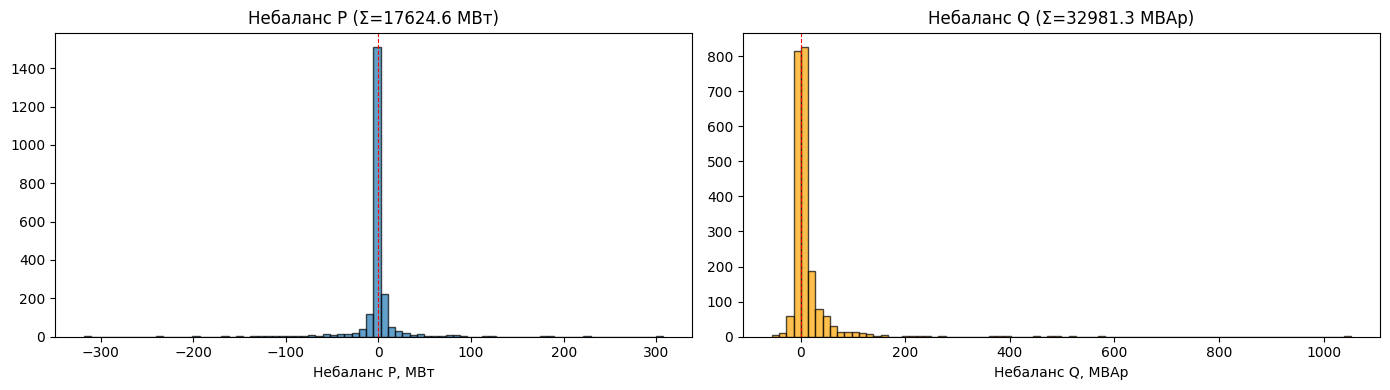

In [14]:
# Небалансы по узлам
imb_p = n_out["imbalance_p"]
imb_q = n_out["imbalance_q"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(imb_p, bins=80, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Небаланс P, МВт")
axes[0].set_title(f"Небаланс P (Σ={np.abs(imb_p).sum():.1f} МВт)")
axes[0].axvline(0, color="red", ls="--", lw=0.8)

axes[1].hist(imb_q, bins=80, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_xlabel("Небаланс Q, МВАр")
axes[1].set_title(f"Небаланс Q (Σ={np.abs(imb_q).sum():.1f} МВАр)")
axes[1].axvline(0, color="red", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

In [15]:
print("=" * 60)
print(f"  СВОДКА: {CASE} → {ALGORITHM.upper()}")
print("=" * 60)
print(f"  Сходимость:  {result.success} ({result.iterations} итераций)")
print(f"  Целевая ф-я: {result.objective_value:.6f}")
print(f"  Узлов:       {len(n_in)}")
print(f"  Ветвей:      {len(br_in)}")
print(f"  Измерений:   {len(m_in)}")
print(f"  ---")
print(f"  ΔV:          max={np.abs(dv).max():.6f} pu, mean={np.abs(dv).mean():.6f} pu")
print(f"  Δδ:          max={np.degrees(np.abs(dd).max()):.4f}°, mean={np.degrees(np.abs(dd).mean()):.4f}°")
print(f"  Невязки:     max={np.abs(residual).max():.4f}, mean={np.abs(residual).mean():.4f}")
print(f"  Σ потерь P:  {loss.sum():.1f} МВт")
print(f"  Σ |небал. P|: {np.abs(imb_p).sum():.1f} МВт")
print(f"  Σ |небал. Q|: {np.abs(imb_q).sum():.1f} МВАр")
print("=" * 60)

  СВОДКА: after_oc → WLS
  Сходимость:  True (5 итераций)
  Целевая ф-я: 109065.157820
  Узлов:       2152
  Ветвей:      2918
  Измерений:   4631
  ---
  ΔV:          max=0.132150 pu, mean=0.005869 pu
  Δδ:          max=5.4168°, mean=0.5771°
  Невязки:     max=1133.1732, mean=10.3084
  Σ потерь P:  478.1 МВт
  Σ |небал. P|: 17624.6 МВт
  Σ |небал. Q|: 32981.3 МВАр
